# Downstream analysis : scRNA-seq dataset on python

Date: 25 June 2026

In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Core scverse libraries
from __future__ import annotations

import anndata as ad
import scanpy as sc

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Import data

This dataset is from the last workshop, which we performed QC and clustering. 

In [2]:
adata = sc.read_h5ad("data_practiced.h5ad")

## Recap

We will check whether our dataset is still including all the information which we need further.

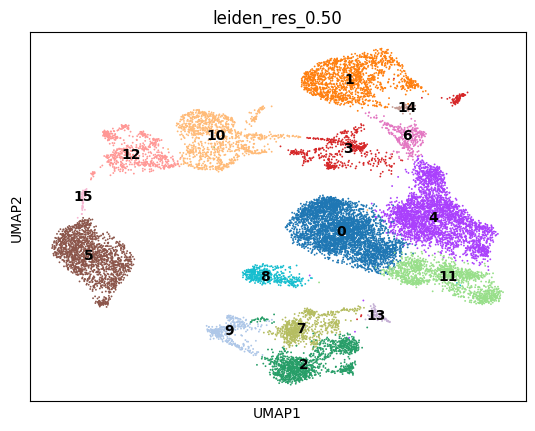

In [3]:
sc.pl.umap(
    adata,
    color="leiden_res_0.50",
    legend_loc="on data",
)

In [4]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

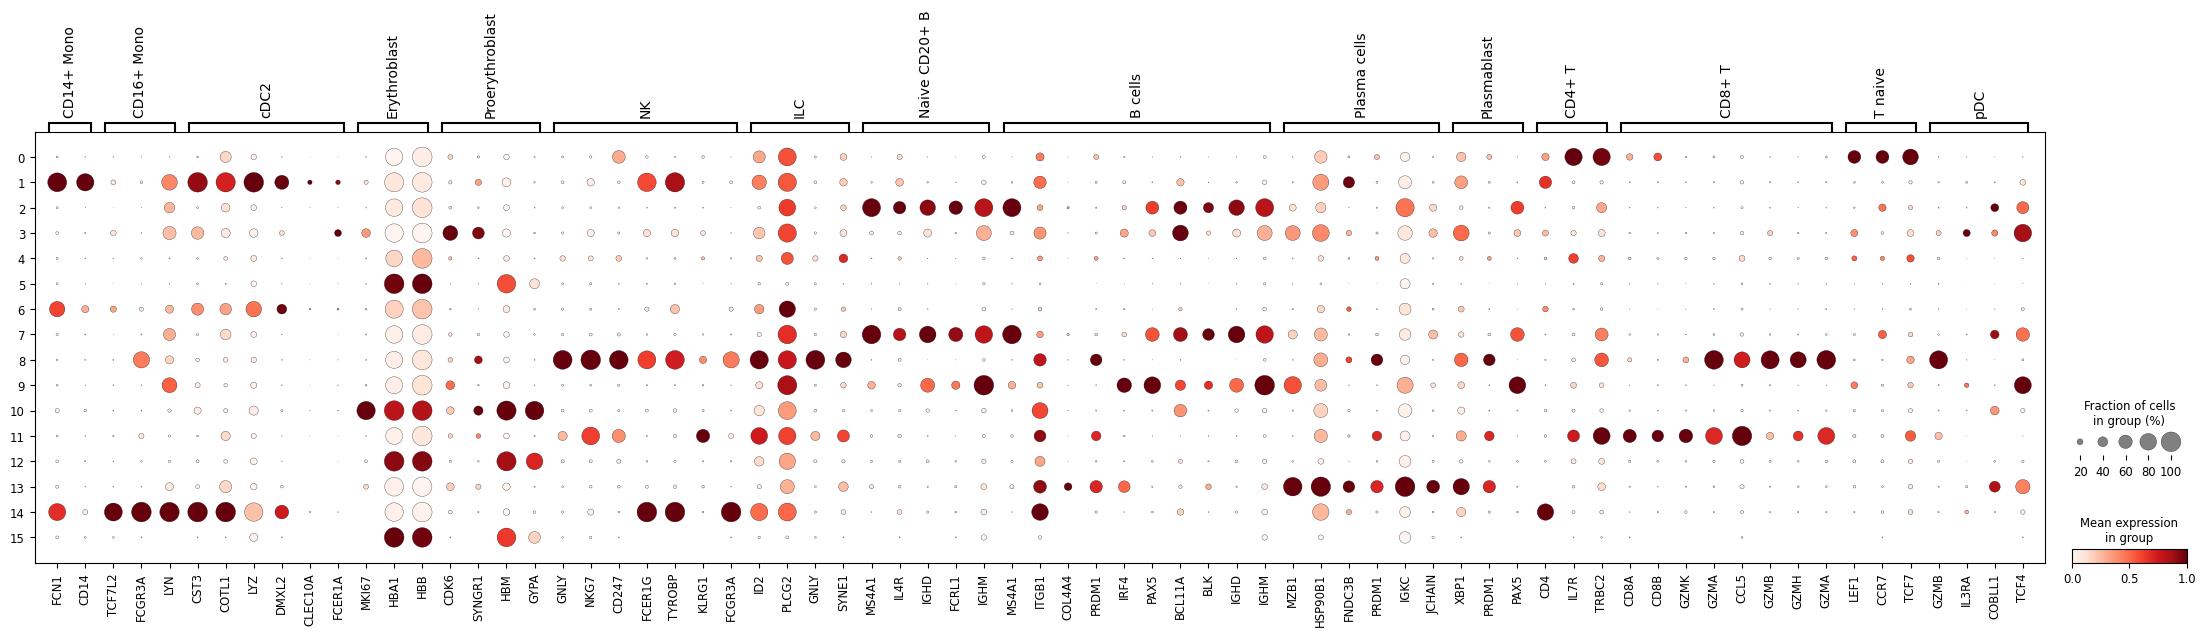

In [5]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.50", 
              standard_scale="var")

## Cluster annotation

Based on the gene expression profile, we will annotate cluster and put the cell type information in our `adata`.

In [6]:
cluster_annotation = {
    "0": "Naive CD4 T cells",
    "1": "CD14+ monocytes",
    "2": "Naive B cells",
    "3": "pDC",
    "4": "Proerythroblast",
    "5": "Erythroblast",
    "6": "Intermediate/activated monocytes",
    "7": "Memory B cells",
    "8": "NK cells",
    "9": "Mature/activated B cells",
    "10": "Cycling erythroblast",
    "11": "Memory/activated T cells",
    "12": "Proerythroblast",
    "13": "Plasma cells / plasmablasts",
    "14": "CD16+ monocytes",
    "15": "Erythroblast",
}

In [7]:
# make sure cluster column is string
adata.obs["leiden_res_0.50"] = adata.obs["leiden_res_0.50"].astype(str)

adata.obs["celltype_annot"] = (
    adata.obs["leiden_res_0.50"]
    .map(cluster_annotation)
    .astype("category")
)

In [8]:
# optional: keep order
adata.obs["celltype_annot"] = pd.Categorical(
    adata.obs["celltype_annot"],
    categories=list(dict.fromkeys(cluster_annotation.values())),
    ordered=True
)

In [9]:
adata.obs["celltype_annot"].value_counts()

celltype_annot
Naive CD4 T cells                   3947
Proerythroblast                     3691
Erythroblast                        1743
CD14+ monocytes                     1439
Memory/activated T cells            1300
Naive B cells                       1252
Cycling erythroblast                1118
Memory B cells                       690
pDC                                  595
NK cells                             457
Mature/activated B cells             359
Intermediate/activated monocytes     309
CD16+ monocytes                       71
Plasma cells / plasmablasts           70
Name: count, dtype: int64

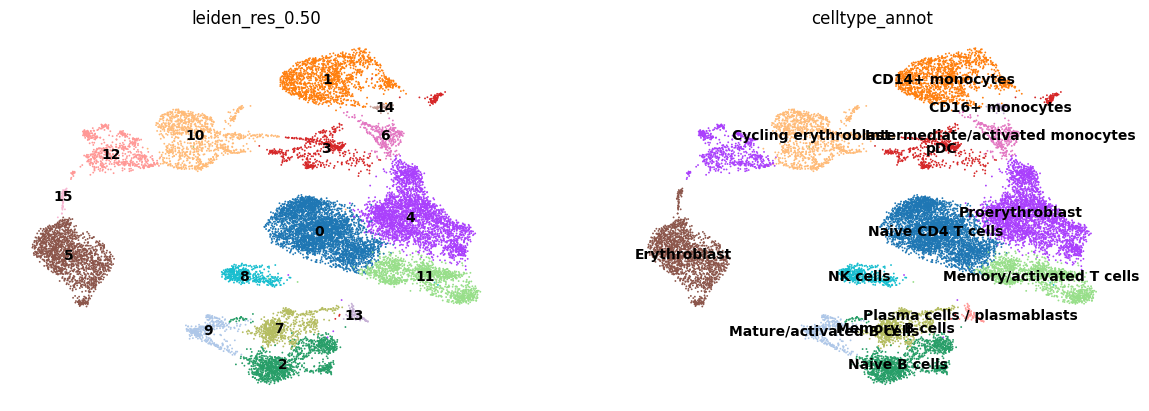

In [10]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.50", "celltype_annot"],
    legend_loc="on data",
    frameon=False
)

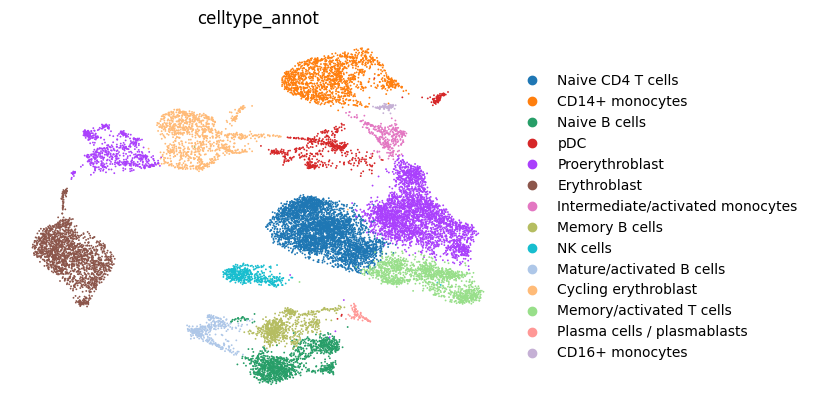

In [11]:
# Put the annotation as a set of label
sc.pl.umap(
    adata,
    color="celltype_annot",
    legend_loc="right margin",
    frameon=False
)

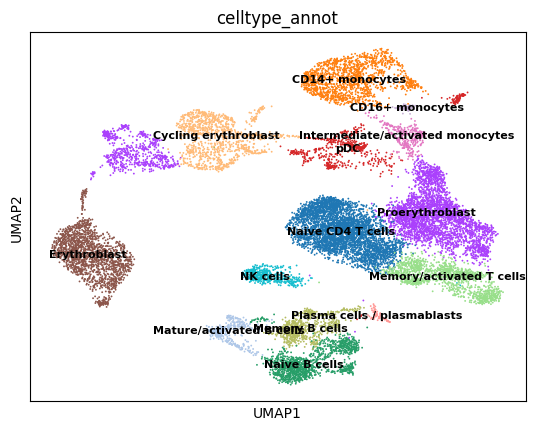

In [12]:
sc.pl.umap(
    adata,
    color="celltype_annot",
    legend_loc="on data",
    legend_fontsize=8 # Adjust font size to smaller ones
)

In [13]:
# Export annotated adata file
adata.write("adata_annotated.h5ad")

# Downstream analysis

## DEG analysis

Here, we will try DEG analysis between two different populations: 

In [14]:
sc.tl.rank_genes_groups(
    adata,
    groupby="celltype_annot",
    groups=["Plasma cells / plasmablasts"],
    reference="Naive B cells",
    method="wilcoxon"
)

We can visualise top20 genes as a plot:

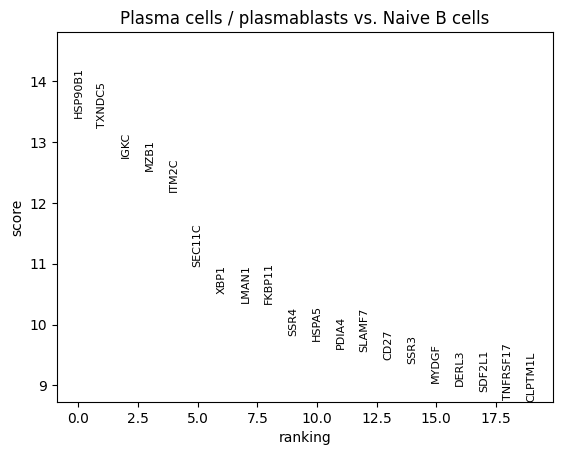

In [15]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False
)

Extract results into a dataframe:

In [16]:
deg = sc.get.rank_genes_groups_df(
    adata,
    group="Plasma cells / plasmablasts"
)

deg.head()

,names,scores,logfoldchanges,pvals,pvals_adj
0,HSP90B1,13.406466,4.152757,5.541795e-41,1.298276e-36
1,TXNDC5,13.243038,5.522570,4.950484e-40,5.798749e-36
2,IGKC,12.736351,5.118823,3.713617e-37,2.899964e-33
3,MZB1,12.534802,4.693410,4.815627e-36,2.256314e-32
4,ITM2C,12.175617,4.806589,4.192122e-34,1.636814e-30


Fiulter significantly regulated genes:

In [17]:
deg_sig = deg[
    (deg["pvals_adj"] < 0.05)
    & (deg["logfoldchanges"] > 1) # This could be adjusted or not applied. 
]

deg_sig.head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,HSP90B1,13.406466,4.152757,5.541795e-41,1.298276e-36
1,TXNDC5,13.243038,5.522570,4.950484e-40,5.798749e-36
2,IGKC,12.736351,5.118823,3.713617e-37,2.899964e-33
3,MZB1,12.534802,4.693410,4.815627e-36,2.256314e-32
4,ITM2C,12.175617,4.806589,4.192122e-34,1.636814e-30
5,SEC11C,10.947825,4.334736,6.806229e-28,9.965595e-25
6,XBP1,10.509661,4.906822,7.797327e-26,1.014822e-22
7,LMAN1,10.365698,3.544372,3.551577e-25,4.160140e-22
8,FKBP11,10.343178,4.979847,4.493824e-25,5.013182e-22
9,SSR4,9.823944,3.110300,8.879965e-23,7.429676e-20


Show top up-regulated genes:

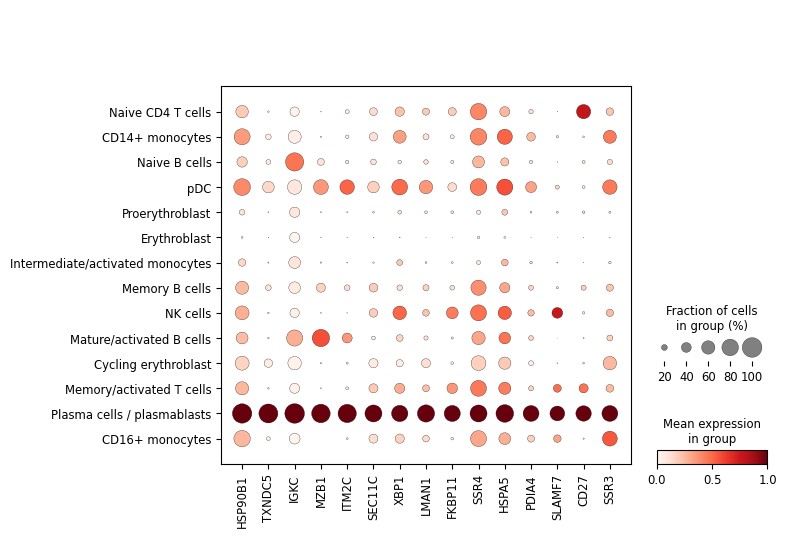

In [18]:
top_genes = deg_sig.head(15)["names"].tolist()

sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="celltype_annot",
    standard_scale="var"
)

In [19]:
# Export DEG result as a table:

deg.to_csv(
    "DEG_Plasma_vs_NaiveB.csv",
    index=False
)

We can also visualise DEG analysis result as a volcano plot.

In [20]:
# Clean up
deg = deg.replace([np.inf, -np.inf], np.nan)
deg = deg.dropna(subset=["logfoldchanges", "pvals_adj"])

In [21]:
# Volcano coordinates
deg["neglog10_padj"] = -np.log10(
    deg["pvals_adj"].clip(lower=1e-300)
)

In [22]:
# Significance
deg["significant"] = deg["pvals_adj"] < 0.05

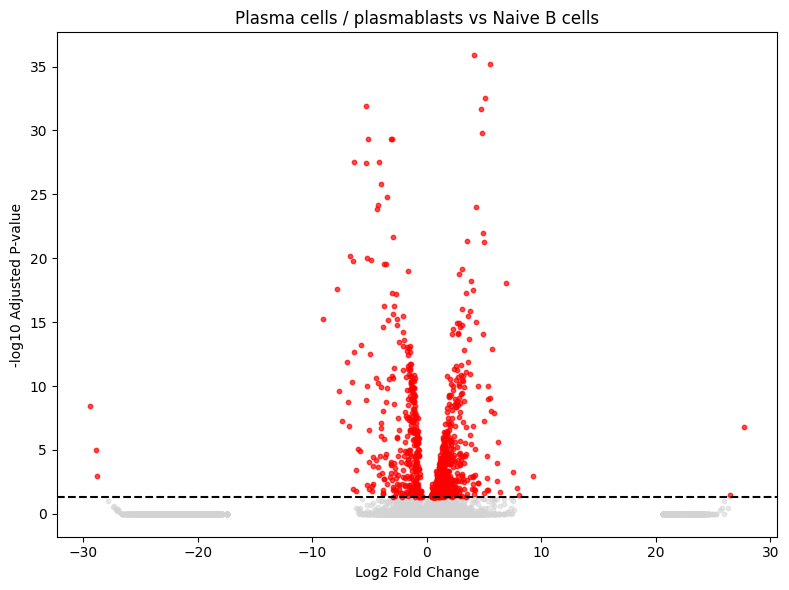

In [23]:
plt.figure(figsize=(8,6))

# Non-significant
plt.scatter(
    deg.loc[~deg["significant"], "logfoldchanges"],
    deg.loc[~deg["significant"], "neglog10_padj"],
    color="lightgrey",
    s=10,
    alpha=0.5
)

# Significant
plt.scatter(
    deg.loc[deg["significant"], "logfoldchanges"],
    deg.loc[deg["significant"], "neglog10_padj"],
    color="red",
    s=10,
    alpha=0.7
)

plt.axhline(-np.log10(0.05), color="black", linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Plasma cells / plasmablasts vs Naive B cells")

plt.tight_layout()
plt.show()

We can label few genes as well:

In [24]:
top_up = deg.sort_values(
    ["pvals_adj", "logfoldchanges"],
    ascending=[True, False]
).head(10)

top_down = deg.sort_values(
    ["pvals_adj", "logfoldchanges"],
    ascending=[True, True]
).head(10)

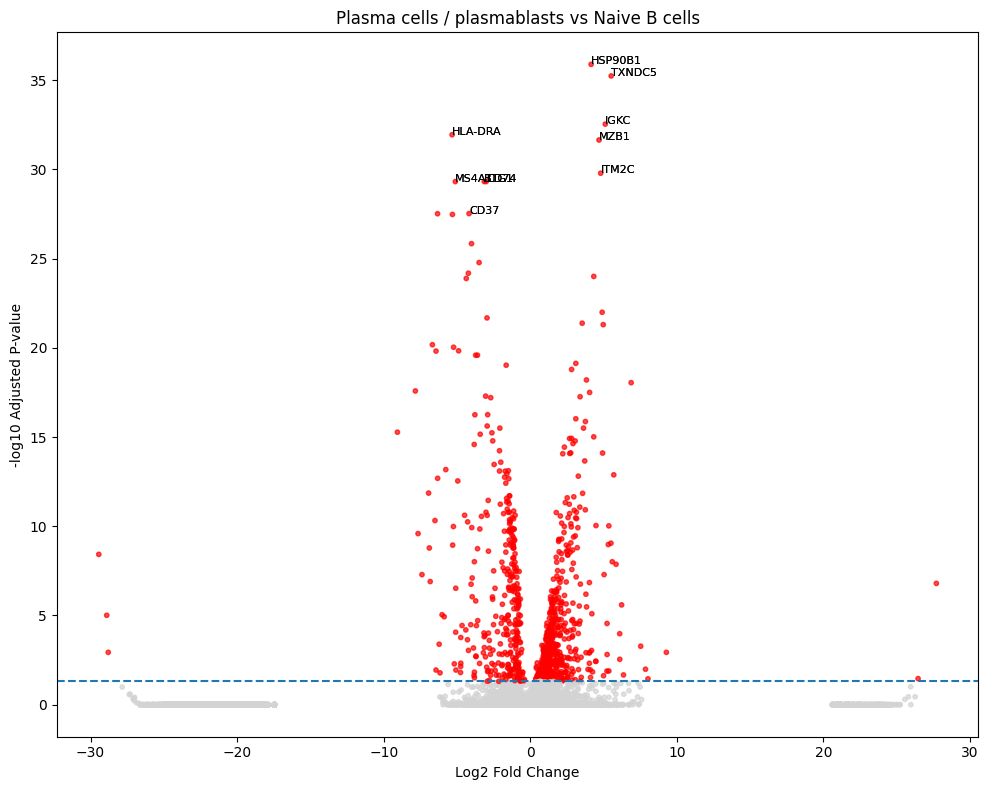

In [25]:
plt.figure(figsize=(10,8))

plt.scatter(
    deg["logfoldchanges"],
    deg["neglog10_padj"],
    c=deg["significant"].map({True: "red", False: "lightgrey"}),
    s=10,
    alpha=0.7
)

for _, row in pd.concat([top_up, top_down]).iterrows():
    plt.text(
        row["logfoldchanges"],
        row["neglog10_padj"],
        row["names"],
        fontsize=8
    )

plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Plasma cells / plasmablasts vs Naive B cells")

plt.tight_layout()
plt.show()

## Pseudotime construction

Pseudotimes rank cells relative to each other according to their respective stage in the developmental process. Less mature cells are assigned small values, while mature cells are assigned large values. The construction usually requires the specification of an initial, or equivalently, a root cell, where the overall process begins.

### Compute t-SNE

Computing of t-SNE may take some minutes. 

In [26]:
sc.tl.tsne(
    adata,
    use_rep="X_pca",
    random_state=42
)

In [27]:
# To see which dimention reduction is available in own data
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap, X_tsne)

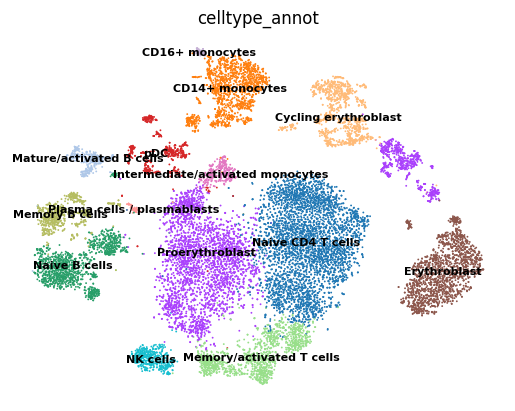

In [28]:
sc.pl.tsne(
    adata,
    color="celltype_annot",
    legend_loc="on data",
    frameon=False,
    legend_fontsize=8
)

To see difference:

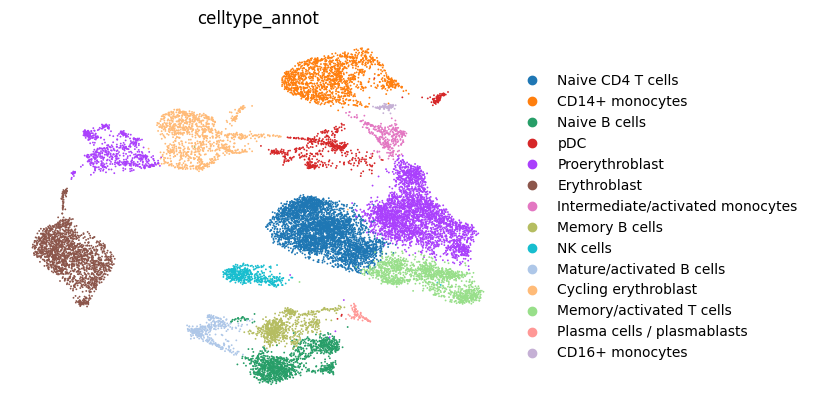

In [29]:
sc.pl.embedding(
    adata,
    basis="umap",
    color="celltype_annot",
    frameon=False
)

### Pseudotime calculation

To calculate diffusion pseudotime (DPT), the corresponding diffusion maps must first be calculated.

In [30]:
sc.tl.diffmap(adata)

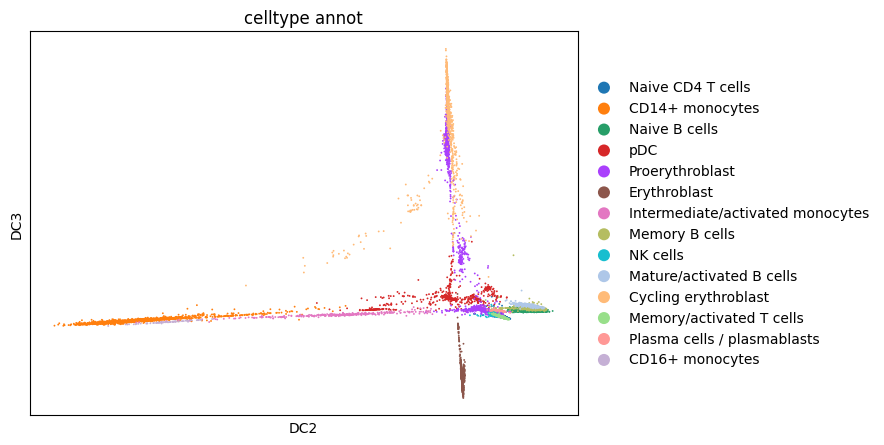

In [31]:
# Setting root cell as described above
root_ixs = adata.obsm["X_diffmap"][:, 3].argmin()

sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["celltype_annot"],
    components=[2, 3],
)

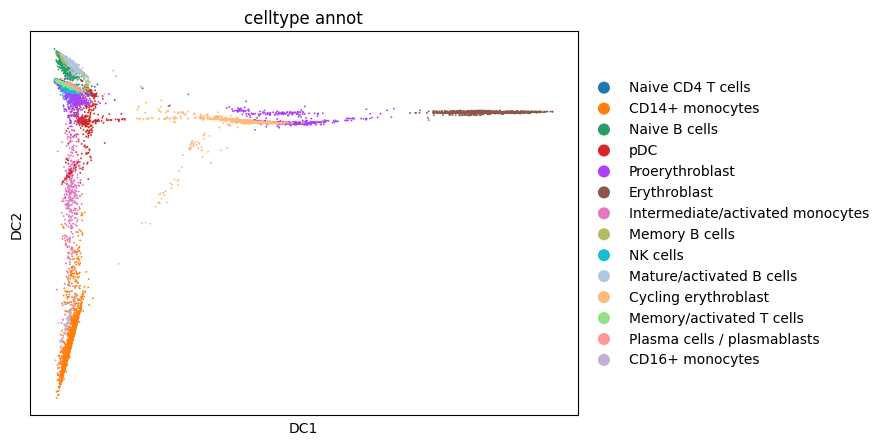

In [32]:
sc.pl.scatter(
    adata,
    basis="diffmap",
    color=["celltype_annot"],
    components=[1, 2],
)

In [33]:
adata.uns["iroot"] = root_ixs

In [34]:
sc.tl.dpt(adata)

Different pseudotime methods give different results. Sometimes, one pseudotime captures the underlying developmental processes more accurately than others. 

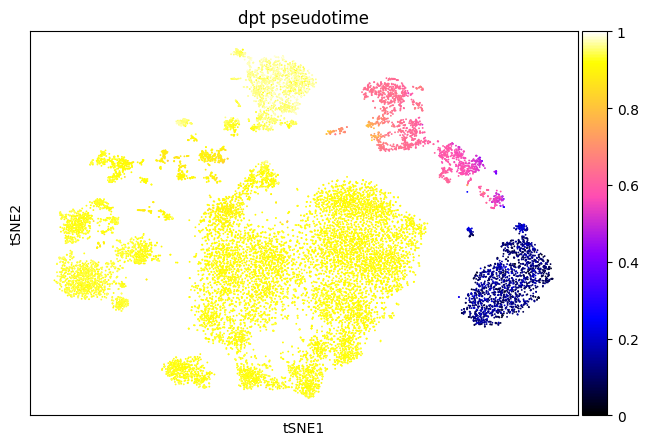

In [35]:
sc.pl.scatter(
    adata,
    basis="tsne",
    color="dpt_pseudotime",
    color_map="gnuplot2",
)

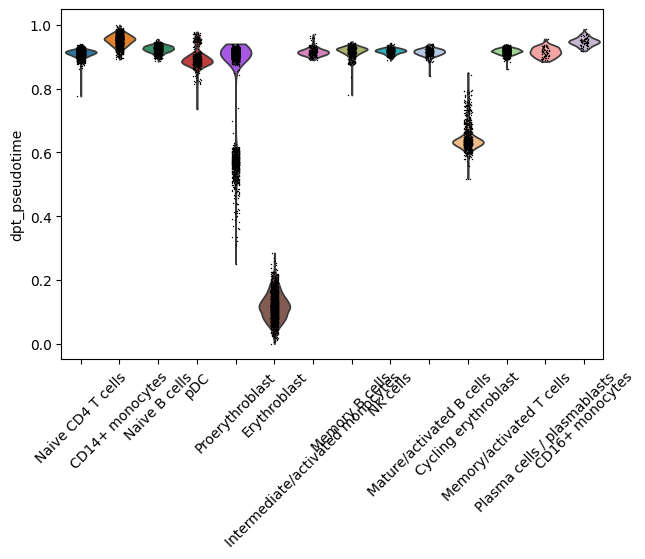

In [36]:
sc.pl.violin(
    adata,
    keys="dpt_pseudotime",
    groupby="celltype_annot",
    rotation=45,
)